In [1]:
import numpy as np
import pandas as pd
import sys
import importlib
import matplotlib.pyplot as plt

sys.path.append('../src')
import policies 
import bbDebiasing2
import wbDebiasing

sys.path.append('folktables-pipeline')
import acsData
import folktablesModelSetup as setup

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss, mean_squared_error

# Building Initial Models

In [2]:
importlib.reload(setup)

acs_year = '2016'
state_names = ['CA', 'OR', 'AK']
state_list = setup.runSetup(acs_year, state_names)

In [22]:
importlib.reload(setup)
ensemble = setup.Ensemble(state_list)
ensemble_meta_preds = ensemble.meta_preds_train
debiasing_targets = ensemble.meta_targets_train

# Black Box Ensembling Experiments

In [25]:
importlib.reload(policies)

# setting up policies
policy_dim = ensemble_meta_preds.shape[1]
component_policies = []
evaluated_component_policies = []
for i, state in enumerate(state_list):
    pol = policies.SingleCoordinateExpert(policy_dim, i)
    # for wb ensembling, will need the policy objects themselves.
    component_policies.append(pol)
    # for bb ensembling, will just need the predictions of the ensembled policies on the training data
    evaluated_component_policies.append(pol.run_given_preds(ensemble_meta_preds))
# generate own policy, which will be simplex policy
own_policy = policies.Simplex(policy_dim)

In [37]:
importlib.reload(bbDebiasing2)
bbModel = bbDebiasing2.bbModel(own_policy, evaluated_component_policies, debiasing_targets, ensemble_meta_preds, 0.01, testing=False)
bbModel.debias()

array([[0.74183971, 0.69422477, 0.69798476],
       [0.79944677, 0.77301624, 0.78506086],
       [0.71174711, 0.69024997, 0.68034042],
       ...,
       [0.90014483, 0.89058394, 0.8734358 ],
       [0.94434825, 0.93959622, 0.92595247],
       [0.71209932, 0.69864014, 0.76136785]], shape=(133130, 3))

# WB Debiasing

In [136]:
importlib.reload(wbDebiasing)
# Current predictions of each model. This is a k x n x k array. 
k = ensemble.n_predictors
n = len(ensemble.meta_preds_train)
wb_preds_train = np.zeros((k,n,k))
for i in range(k):
    wb_preds_train[i, np.arange(n), i] = ensemble.meta_preds_train[np.arange(n), i]

# policies are all simplex policy 
wb_policies = [policies.Simplex(k) for i in range(k)]

wbModel = wbDebiasing.wbModel(wb_policies, debiasing_targets, wb_preds_train, 0.01)
wbModel.debias()

array([[[0.72215193, 0.67879951, 0.68382236],
        [0.82405653, 0.7454801 , 0.73929671],
        [0.65525122, 0.61471576, 0.60822191],
        ...,
        [0.88692336, 0.87969349, 0.87188013],
        [0.93326155, 0.91465739, 0.90726915],
        [0.72267045, 0.71053019, 0.70178142]],

       [[0.71825753, 0.71612138, 0.69914404],
        [0.77076065, 0.80113897, 0.74719767],
        [0.66231548, 0.63039952, 0.59709783],
        ...,
        [0.86305116, 0.8560106 , 0.83669659],
        [0.91622476, 0.93820128, 0.90276106],
        [0.71031048, 0.71154285, 0.67261936]],

       [[0.73697797, 0.71779263, 0.73669458],
        [0.76155515, 0.74035143, 0.79397018],
        [0.68214004, 0.64253856, 0.64581547],
        ...,
        [0.87824741, 0.86494221, 0.81787392],
        [0.91311415, 0.90354237, 0.90727433],
        [0.7245968 , 0.69757218, 0.7250914 ]]], shape=(3, 133130, 3))

In [110]:

policy_outputs = np.array([wbModel.policies[i].run_given_preds(wbModel.preds_by_models[i]) for i in range(len(wbModel.policies))])
max_model_masks = wbModel._generate_maximal_model_masks(wbModel.preds_by_models, policy_outputs) # shape k x n
model_ls_masks = wbModel._generate_model_ls_masks(policy_outputs) # shape k x d x m x n

In [137]:
len(wbModel.targets_by_round)

36

In [125]:
k = 3
d = 4
m = 2
n = 5

model_ls_masks = np.arange(k*d*m*n).reshape(k,d,m,n) #shape k x d x m x n
max_model_masks = np.arange(start=k*d*m*n, stop=k*d*m*n+k*n).reshape(k,n) # shape k x n


In [128]:
foo = np.expand_dims(model_ls_masks, -2)*max_model_masks


In [132]:
max_model_masks[0]

array([120, 121, 122, 123, 124])

# Basic Data Exploration and Visualization

Text(0.5, 1.0, 'Normalized Income Distribution by State (Under 100k)')

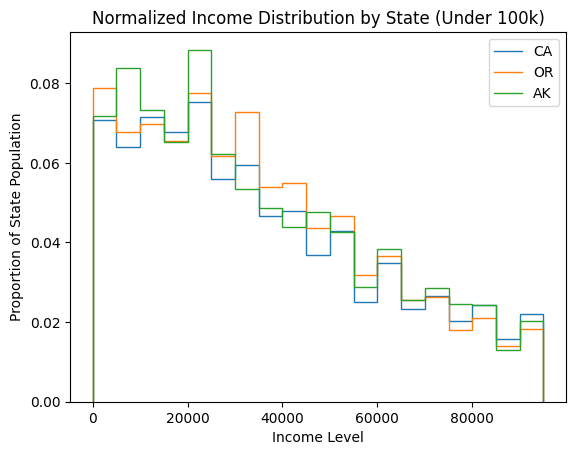

In [13]:
for state in stateList:
    counts, bins = np.histogram(state.targets, bins=np.arange(0,100000,5000))
    plt.stairs(counts/len(state.targets), bins, label=state.name)
plt.legend()
plt.xlabel('Income Level')
plt.ylabel('Proportion of State Population')
plt.title('Normalized Income Distribution by State (Under 100k)')

In [14]:
mses = np.zeros((len(stateList), len(stateList)))

for i,state1 in enumerate(stateList):
    for j,state2 in enumerate(stateList):
        # state 1 model's performance on state 2 test data
        mses[i][j] = mean_squared_error(state2.target_test, state1.model.predict_proba(state2.features_test)[:,1])

In [15]:
df = pd.DataFrame(mses, stateNames, stateNames)
df.style.apply(lambda col: ['font-weight:bold' if x==col.min() else '' for x in col], axis=1)

,CA,OR,AK
CA,0.145102,0.152602,0.154560
OR,0.153803,0.146826,0.158409
AK,0.156537,0.157822,0.151193


In [70]:
for state in stateList:
    zero_one_err = (state.meta_model_preds_test==state.meta_model_targets_test).sum()/len(state.meta_model_preds_test)
    print(zero_one_err)

0.7891757365441576
0.7836407377706496
0.7814258911819888
